**Đọc dataset**

In [37]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "go_emotions_dataset.csv"


df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/go-emotions-google-emotions-dataset",
    file_path
)

# Khai báo cấu trúc hệ thống phân loại 28 nhãn chuẩn của Google
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]



/tmp/ipykernel_6123/2057014050.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'go-emotions-google-emotions-dataset' dataset.


**Gom cụm**

In [38]:
# Gom cụm các rater đánh giá cùng một câu bình luận lại với nhau
grouped = df.groupby(['id', 'text'])[emotion_labels].sum().reset_index()
print(f"Số lượng câu bình luận độc nhất sau khi gom cụm: {len(grouped)} câu.")

# Nhãn cảm xúc nào được ít nhất 2 chuyên gia chọn mới tính là 1, dưới 2 phiếu bầu sẽ bị hủy (= 0)
for col in emotion_labels:
    grouped[col] = (grouped[col] >= 2).astype(int)

# Tính tổng số nhãn được kích hoạt cho mỗi câu
grouped['has_label'] = grouped[emotion_labels].sum(axis=1)
# Chỉ giữ lại các câu có ít nhất 1 nhãn cảm xúc đạt sự đồng thuận từ 2 người trở lên
grouped_clean = grouped[grouped['has_label'] > 0].drop(columns=['has_label'])

print(f"🔹 Số lượng câu bình luận sạch thu được: {len(grouped_clean)} câu.")

# Xem thử 3 dòng đầu tiên sau khi làm sạch
grouped_clean.head(3)

Số lượng câu bình luận độc nhất sau khi gom cụm: 58011 câu.
🔹 Số lượng câu bình luận sạch thu được: 54263 câu.


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,You blew it. They played you like a fiddle.,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Làm sạch**

In [39]:
import re
import unicodedata
import nltk
from nltk.stem import WordNetLemmatizer

# Tải thư viện cần thiết
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def clean_text_for_cnn(text, use_lemmatization=False):
    # 1. Tránh lỗi crash nếu dữ liệu bị trống (NaN)
    if not isinstance(text, str):
        return ""

    # 2. Đưa về chữ thường
    text = text.lower()

    # 3. Đồng bộ hóa "dấu nháy" và xử lý Unicode
    text = re.sub(r"[’‘`´]", "'", text)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 4. Khai triển từ viết tắt
    contractions = {
        r"i'm": "i am", r"don't": "do not", r"doesn't": "does not",
        r"can't": "cannot", r"won't": "will not", r"isn't": "is not",
        r"aren't": "are not", r"haven't": "have not", r"hasn't": "has not",
        r"didn't": "did not", r"it's": "it is", r"that's": "that is",
        r"you're": "you are", r"i've": "i have", r"i'll": "i will"
    }
    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text)

    # Vớt những cụm viết tắt đuôi còn sót
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # 5. Lọc ký tự đặc biệt
    text = re.sub(r"[^a-z0-9\s\!\?\_]", " ", text)

    # BỔ SUNG QUAN TRỌNG: Tách dấu ! và ? ra khỏi chữ để Tokenizer đếm đúng
    text = re.sub(r'([!\?])', r' \1 ', text)

    # 6. Ép các ký tự lặp lại vô nghĩa (soooo -> so)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 7. Gom khoảng trắng thừa và cắt tỉa
    text = re.sub(r"\s+", " ", text).strip()

    # 8. Lemmatization (Ép gốc từ)
    if use_lemmatization:
        words = text.split()
        text = " ".join([lemmatizer.lemmatize(w, pos='v') for w in words])

    return text

# ========================================================
# ÁP DỤNG HÀM LÀM SẠCH LÊN TẬP DỮ LIỆU
# ========================================================

df_ready = grouped_clean.copy()
df_ready = df_ready.dropna(subset=['text'])

# FIX: Bật use_lemmatization=True vì lát nữa ta tự train Word2Vec
print("⏳ Đang làm sạch văn bản và ép gốc từ (Lemmatization)...")
df_ready['text'] = df_ready['text'].apply(lambda x: clean_text_for_cnn(x, use_lemmatization=True))

df_ready = df_ready[df_ready['text'] != ""]

print(f"✅ Số lượng câu bình luận sạch sau khi qua bộ lọc text: {len(df_ready)} câu.\n")
display(df_ready.head(5))

⏳ Đang làm sạch văn bản và ép gốc từ (Lemmatization)...
✅ Số lượng câu bình luận sạch sau khi qua bộ lọc text: 54260 câu.



,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,fast as name will carry me seriously uptown to...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,you blow it they play you like a fiddle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,tl dr no more superbowls for name get ready fo...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,eczb527,so much time save not,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,eczb6r7,emote have a ridiculous amount of effort put i...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**Chia tập train test valid**

In [40]:
from sklearn.model_selection import train_test_split

# 1. Tách ma trận đầu vào X (văn bản SẠCH) và ma trận đầu ra Y (28 nhãn)
X_text = df_ready['text'].astype(str).values      # <--- Sửa thành df_ready
Y_matrix = df_ready[emotion_labels].values        # <--- Sửa thành df_ready

# 2. Lần tách thứ nhất: Giữ lại 80% cho tập Train, đẩy 20% còn lại vào tập tạm (Temp)
X_train_text, X_temp_text, Y_train, Y_temp = train_test_split(
    X_text, Y_matrix, test_size=0.20, random_state=42
)

# 3. Lần tách thứ hai: Chia đôi 50/50 tập tạm (Temp) để lấy ra đúng 10% Val và 10% Test
X_val_text, X_test_text, Y_val, Y_test = train_test_split(
    X_temp_text, Y_temp, test_size=0.50, random_state=42
)

print(f"Tập Huấn luyện (Train - 80%): {X_train_text.shape[0]} câu.")
print(f"Tập Phát triển/Kiểm định (Val - 10%): {X_val_text.shape[0]} câu.")
print(f"Tập Kiểm thử (Test - 10%): {X_test_text.shape[0]} câu.")
print(f"Tổng cộng: {X_train_text.shape[0] + X_val_text.shape[0] + X_test_text.shape[0]} câu.")

Tập Huấn luyện (Train - 80%): 43408 câu.
Tập Phát triển/Kiểm định (Val - 10%): 5426 câu.
Tập Kiểm thử (Test - 10%): 5426 câu.
Tổng cộng: 54260 câu.


**Tiền trạm**

In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

print("🛠️ ĐANG MÃ HÓA TỪ VỰNG (TOKENIZATION) & ĐỆM CHUỖI (PADDING)...")
print("-" * 60)

# 1. Khởi tạo Tokenizer
# Giới hạn bộ từ vựng ở 20,000 từ phổ biến nhất. Các từ hiếm gặp sẽ bị gộp chung thành nhãn <OOV>
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")

# BẮT BUỘC: Chỉ fit Tokenizer trên tập Train để chống rò rỉ dữ liệu
print("⏳ Đang Fit Tokenizer trên tập Train...")
tokenizer.fit_on_texts(X_train_text)

# Xem thử có bao nhiêu từ duy nhất trong tập Train
word_index = tokenizer.word_index
print(f"✅ Số lượng từ duy nhất trong từ điển thực tế: {len(word_index)}")

# 2. Chuyển đổi văn bản thành chuỗi các con số
print("⏳ Đang chuyển đổi chữ thành số (texts_to_sequences)...")
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# 3. Đệm chuỗi (Padding)
# 3. Đệm chuỗi (Padding)
MAX_LEN = 50 # Giới hạn độ dài mỗi câu là 50 từ

print("⏳ Đang ép độ dài câu (Padding)...")
# SỬA Ở ĐÂY: Chuyển 'post' thành 'pre' để bảo toàn masking cho LSTM
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')

print("\n📊 KIỂM TRA KÍCH THƯỚC MA TRẬN SAU PADDING:")
print("-" * 60)
print(f"   - X_train_pad shape: {X_train_pad.shape}")
print(f"   - X_val_pad shape  : {X_val_pad.shape}")
print(f"   - X_test_pad shape : {X_test_pad.shape}")
print("-" * 60)

🛠️ ĐANG MÃ HÓA TỪ VỰNG (TOKENIZATION) & ĐỆM CHUỖI (PADDING)...
------------------------------------------------------------
⏳ Đang Fit Tokenizer trên tập Train...
✅ Số lượng từ duy nhất trong từ điển thực tế: 21460
⏳ Đang chuyển đổi chữ thành số (texts_to_sequences)...
⏳ Đang ép độ dài câu (Padding)...

📊 KIỂM TRA KÍCH THƯỚC MA TRẬN SAU PADDING:
------------------------------------------------------------
   - X_train_pad shape: (43408, 50)
   - X_val_pad shape  : (5426, 50)
   - X_test_pad shape : (5426, 50)
------------------------------------------------------------


Word2Vec

In [42]:
# 0. Cài đặt thư viện gensim nếu môi trường chưa có
!pip install -q gensim

from gensim.models import Word2Vec
import numpy as np

# 1. Chuẩn bị dữ liệu cho Gensim (Đầu vào là list các từ)
sentences_for_w2v = [str(sentence).split() for sentence in X_train_text]

# 2. Huấn luyện mô hình Word2Vec từ đầu
# 3. Đệm chuỗi (Padding)
# 3. Đệm chuỗi (Padding)
MAX_LEN = 50 # Giới hạn độ dài mỗi câu là 50 từ

print("⏳ Đang ép độ dài câu (Padding)...")
# SỬA LẠI: Chuyển về 'post' để tương thích với GPU (cuDNN)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

# 3. Tạo Ma trận Nhúng (Embedding Matrix) tối ưu RAM
EMBEDDING_DIM = 100

# FIX LỖI TỐI ƯU: Chỉ lấy kích thước tối đa là MAX_VOCAB_SIZE (20000)
# Nếu từ điển thực tế nhỏ hơn 20.000 thì lấy len(word_index) + 1
vocab_size = min(len(word_index) + 1, MAX_VOCAB_SIZE)
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

oov_count = 0
# Bơm vector vào Ma trận
for word, i in word_index.items():
    if i >= vocab_size:
        # Bỏ qua không bơm vector cho những từ nằm ngoài top 20.000 (đã bị Tokenizer vứt bỏ)
        continue

    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
    else:
        oov_count += 1

print(f"🔹 Kích thước Embedding Matrix cuối cùng: {embedding_matrix.shape}")
print(f"🔹 Số lượng từ không có vector (OOV) trong top {vocab_size}: {oov_count} từ")

⏳ Đang ép độ dài câu (Padding)...
🔹 Kích thước Embedding Matrix cuối cùng: (20000, 100)
🔹 Số lượng từ không có vector (OOV) trong top 20000: 9138 từ


**Bi LSTM**

In [43]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout # Thêm Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryFocalCrossentropy # Thêm Focal Loss

print("🧠 ĐANG XÂY DỰNG KIẾN TRÚC MẠNG BI-LSTM + WORD2VEC...")
print("-" * 60)

# Khởi tạo mô hình
model = Sequential()

# SỬA Ở ĐÂY: Bắt buộc phải có lớp Input để định hình đầu vào và giúp Masking hoạt động
model.add(Input(shape=(MAX_LEN,)))

# 1. Lớp Nhúng (Embedding Layer)
model.add(Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    # Đã xóa input_length=MAX_LEN ở đây vì đã dùng lớp Input ở trên
    trainable=True,
    mask_zero=True,
    name="Custom_Word2Vec_Embedding"
))

# 2. Lớp LSTM 2 chiều (Bidirectional LSTM)
model.add(Bidirectional(LSTM(128, return_sequences=False), name="Bi_LSTM_Layer"))

# Dropout 0.3
model.add(Dropout(0.3, name="Dropout_1"))

# 3. Lớp Ẩn (Hidden Dense Layer)
model.add(Dense(64, activation='relu', name="Dense_Feature_Layer"))
model.add(Dropout(0.2, name="Dropout_2"))

# 4. Lớp Đầu ra (Output Layer) cho 28 nhãn cảm xúc
model.add(Dense(28, activation='sigmoid', name="Output_28_Emotions"))

# 5. Biên dịch mô hình (Compile)
optimizer = Adam(learning_rate=0.001)
model.compile(
    # SỬA Ở ĐÂY: Dùng Focal Loss để xử lý mất cân bằng dữ liệu nghiêm trọng
    loss=BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
    optimizer=optimizer,
    metrics=['binary_accuracy']
)

print("✅ KHỞI TẠO THÀNH CÔNG! Bảng tóm tắt kiến trúc mạng:")
print("=" * 60)
model.summary()

🧠 ĐANG XÂY DỰNG KIẾN TRÚC MẠNG BI-LSTM + WORD2VEC...
------------------------------------------------------------
✅ KHỞI TẠO THÀNH CÔNG! Bảng tóm tắt kiến trúc mạng:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Custom_Word2Vec_Embedding       │ (None, 50, 100)        │     2,000,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Bi_LSTM_Layer (Bidirectional)   │ (None, 256)            │       234,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_Feature_Layer (Dense)     │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_28_Emotions (Dense)      │ (None, 28)             │         1,820 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,252,764 (8.59 MB)

 Trainable params: 2,252,764 (8.59 MB)

 Non-trainable params: 0 (0.00 B)

In [44]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("🚀 BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH BiLSTM + Word2Vec...")
print("-" * 60)

# =====================================================
# CALLBACKS
# =====================================================

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_bilstm_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# =====================================================
# TRAIN
# =====================================================

history = model.fit(
    X_train_pad,
    Y_train,
    validation_data=(X_val_pad, Y_val),
    epochs=20,
    batch_size=128,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ],
    verbose=1
)

print("\n✅ HUẤN LUYỆN HOÀN TẤT!")

🚀 BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH BiLSTM + Word2Vec...
------------------------------------------------------------
Epoch 1/20
337/340 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - binary_accuracy: 0.9029 - loss: 0.0679
Epoch 1: val_loss improved from None to 0.03420, saving model to best_bilstm_model.keras

Epoch 1: finished saving model to best_bilstm_model.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 16s 29ms/step - binary_accuracy: 0.9456 - loss: 0.0482 - val_binary_accuracy: 0.9626 - val_loss: 0.0342 - learning_rate: 0.0010
Epoch 2/20
339/340 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - binary_accuracy: 0.9629 - loss: 0.0348
Epoch 2: val_loss improved from 0.03420 to 0.03053, saving model to best_bilstm_model.keras

Epoch 2: finished saving model to best_bilstm_model.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - binary_accuracy: 0.9633 - loss: 0.0340 - val_binary_accuracy: 0.9651 - val_loss: 0.0305 - learning_rate: 0.0010
Epoch 3/20
338/340 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - binary_accuracy: 0.9656 - loss: 0.

**Tìm ngưỡng tối ưu F1**

In [45]:
from sklearn.metrics import f1_score
import numpy as np
import time

print("🔎 ĐANG TÌM NGƯỠNG TỐI ƯU (THRESHOLD TUNING) CHO TỪNG NHÃN TRÊN TẬP VAL...")
print("-" * 60)
start_time = time.time()

# 1. Dự đoán xác suất trên tập Validation
print("⏳ Đang tính toán xác suất từ mô hình (model_optimized)...")
# Thêm verbose=0 để ẩn thanh tiến trình của Keras cho đỡ rác màn hình
Y_val_pred_probs = model.predict(X_val_pad, verbose=0)

best_thresholds = {}
f1_scores = {}

# FIX LỖI: Đảm bảo Y_val là Numpy Array để không bị lỗi Y_val[:, i]
Y_val_array = Y_val.values if hasattr(Y_val, 'values') else Y_val

print("🎯 Bắt đầu quét ngưỡng cho 28 nhãn cảm xúc...\n")
for i, label in enumerate(emotion_labels):
    best_thresh = 0.5
    best_f1 = 0.0

    # Dùng bước nhảy 0.05 (đủ chuẩn xác và nhanh hơn rất nhiều so với 0.01)
    for thresh in np.arange(0.05, 0.96, 0.01):
        thresh = round(thresh, 2) # Xử lý lỗi số thực của Numpy (vd: 0.15000000002)

        y_pred_binary = (Y_val_pred_probs[:, i] >= thresh).astype(int)
        y_true = Y_val_array[:, i]

        current_f1 = f1_score(y_true, y_pred_binary, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh

    best_thresholds[label] = best_thresh
    f1_scores[label] = best_f1

    # In ra với định dạng căn lề chuẩn
    print(f"Nhãn: [{label.upper().ljust(15)}] | Ngưỡng tối ưu: {best_thresh:.2f} | F1-Score: {best_f1:.4f}")

macro_f1 = np.mean(list(f1_scores.values()))
end_time = time.time()

print("=" * 60)
print(f"🏆 ĐIỂM MACRO F1 TRUNG BÌNH CỦA MÔ HÌNH (VAL): {macro_f1:.4f}")
print(f"⏳ Thời gian quét: {end_time - start_time:.2f} giây")
print("=" * 60)

🔎 ĐANG TÌM NGƯỠNG TỐI ƯU (THRESHOLD TUNING) CHO TỪNG NHÃN TRÊN TẬP VAL...
------------------------------------------------------------
⏳ Đang tính toán xác suất từ mô hình (model_optimized)...
🎯 Bắt đầu quét ngưỡng cho 28 nhãn cảm xúc...

Nhãn: [ADMIRATION     ] | Ngưỡng tối ưu: 0.43 | F1-Score: 0.6673
Nhãn: [AMUSEMENT      ] | Ngưỡng tối ưu: 0.42 | F1-Score: 0.7743
Nhãn: [ANGER          ] | Ngưỡng tối ưu: 0.43 | F1-Score: 0.4298
Nhãn: [ANNOYANCE      ] | Ngưỡng tối ưu: 0.39 | F1-Score: 0.3148
Nhãn: [APPROVAL       ] | Ngưỡng tối ưu: 0.33 | F1-Score: 0.3058
Nhãn: [CARING         ] | Ngưỡng tối ưu: 0.33 | F1-Score: 0.3121
Nhãn: [CONFUSION      ] | Ngưỡng tối ưu: 0.34 | F1-Score: 0.2851
Nhãn: [CURIOSITY      ] | Ngưỡng tối ưu: 0.40 | F1-Score: 0.4189
Nhãn: [DESIRE         ] | Ngưỡng tối ưu: 0.30 | F1-Score: 0.4416
Nhãn: [DISAPPOINTMENT ] | Ngưỡng tối ưu: 0.34 | F1-Score: 0.1787
Nhãn: [DISAPPROVAL    ] | Ngưỡng tối ưu: 0.33 | F1-Score: 0.3102
Nhãn: [DISGUST        ] | Ngưỡng tối ưu: 0.34 

**Đánh giá trên test**

In [46]:
from sklearn.metrics import classification_report
import numpy as np
import time

print("📊 ĐANG ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM THỬ (TEST SET)...")
print("-" * 60)
start_time = time.time()

# 1. Dự đoán xác suất trên tập Test
print("⏳ Đang tính toán xác suất từ model_optimized...")
# Thêm verbose=0 để ẩn thanh tiến trình nhảy liên tục, giữ output gọn gàng
Y_test_pred_probs = model.predict(X_test_pad, verbose=0)

# Khởi tạo ma trận rỗng chứa kết quả nhị phân
Y_test_pred_binary = np.zeros_like(Y_test_pred_probs)

# FIX LỖI: Chuyển Y_test về Numpy Array để đồng bộ cấu trúc, tránh lỗi của classification_report
Y_test_array = Y_test.values if hasattr(Y_test, 'values') else Y_test

# 2. Áp dụng ngưỡng cắt (threshold) tối ưu của từng nhãn từ tập Validation
for i, label in enumerate(emotion_labels):
    thresh = best_thresholds[label]
    Y_test_pred_binary[:, i] = (Y_test_pred_probs[:, i] >= thresh).astype(int)

# 3. In Báo cáo phân loại (Classification Report)
print("\n" + "=" * 65)
print("🏆 BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST (CLASSIFICATION REPORT)")
print("=" * 65)

report = classification_report(
    Y_test_array,
    Y_test_pred_binary,
    target_names=emotion_labels,
    zero_division=0
)
print(report)

end_time = time.time()
print("=" * 65)
print(f"⏳ Thời gian đánh giá: {end_time - start_time:.2f} giây")
print("=" * 65)

📊 ĐANG ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP KIỂM THỬ (TEST SET)...
------------------------------------------------------------
⏳ Đang tính toán xác suất từ model_optimized...

🏆 BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST (CLASSIFICATION REPORT)
                precision    recall  f1-score   support

    admiration       0.68      0.64      0.66       510
     amusement       0.79      0.81      0.80       316
         anger       0.43      0.38      0.40       184
     annoyance       0.28      0.30      0.29       314
      approval       0.27      0.35      0.31       372
        caring       0.22      0.32      0.26       139
     confusion       0.21      0.37      0.27       154
     curiosity       0.43      0.42      0.42       286
        desire       0.27      0.48      0.34        82
disappointment       0.20      0.18      0.19       162
   disapproval       0.27      0.37      0.31       247
       disgust       0.36      0.40      0.38       124
 embarrassment       0.22      0.15   

**vẽ biểu đồ**

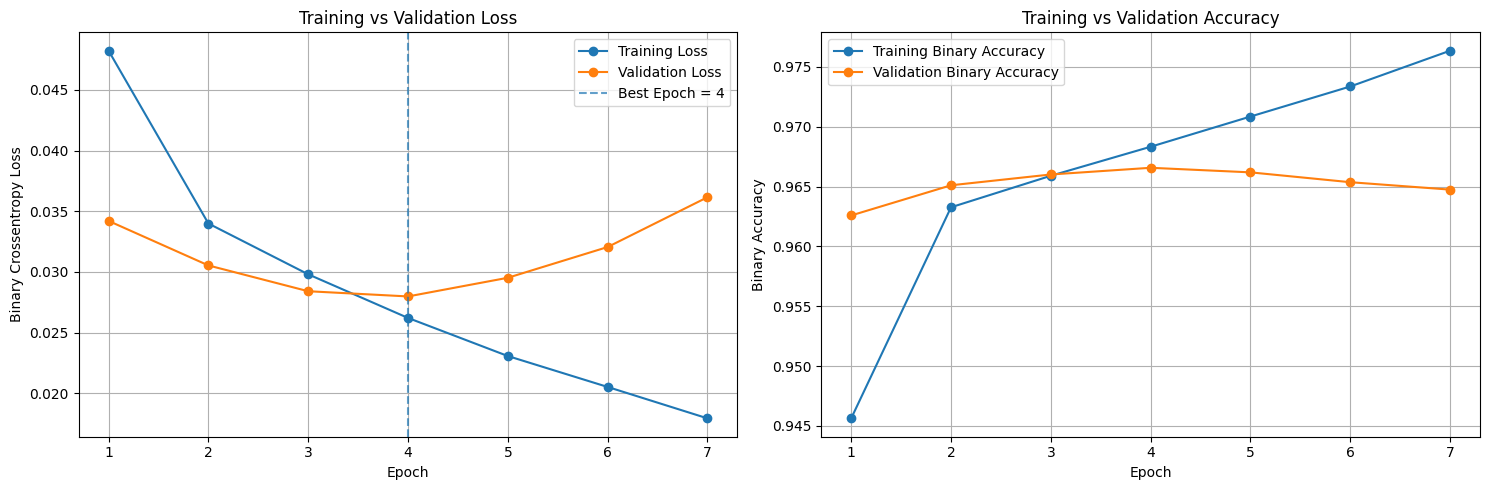

🏆 Best Epoch: 4
🏆 Best Validation Loss: 0.0280
🏆 Epochs thực tế đã chạy: 7
💾 Đã lưu: BiLSTM_Training_History.png


In [47]:
import matplotlib.pyplot as plt
import numpy as np

# =====================================================
# VẼ ĐỒ THỊ QUÁ TRÌNH HỌC
# =====================================================

loss = history.history['loss']
val_loss = history.history['val_loss']

acc = history.history.get('binary_accuracy')
val_acc = history.history.get('val_binary_accuracy')

epochs = np.arange(1, len(loss) + 1)

best_epoch = np.argmin(val_loss) + 1
best_val_loss = np.min(val_loss)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

# =====================================================
# LOSS
# =====================================================

axes[0].plot(
    epochs,
    loss,
    marker='o',
    label='Training Loss'
)

axes[0].plot(
    epochs,
    val_loss,
    marker='o',
    label='Validation Loss'
)

axes[0].axvline(
    best_epoch,
    linestyle='--',
    alpha=0.7,
    label=f'Best Epoch = {best_epoch}'
)

axes[0].set_title('Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(True)

# =====================================================
# ACCURACY
# =====================================================

if acc is not None and val_acc is not None:

    axes[1].plot(
        epochs,
        acc,
        marker='o',
        label='Training Binary Accuracy'
    )

    axes[1].plot(
        epochs,
        val_acc,
        marker='o',
        label='Validation Binary Accuracy'
    )

    axes[1].set_title('Training vs Validation Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Binary Accuracy')
    axes[1].legend()
    axes[1].grid(True)

plt.tight_layout()

# Lưu ảnh chất lượng cao
plt.savefig(
    'BiLSTM_Training_History.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =====================================================
# THỐNG KÊ
# =====================================================

print("=" * 60)
print(f"🏆 Best Epoch: {best_epoch}")
print(f"🏆 Best Validation Loss: {best_val_loss:.4f}")
print(f"🏆 Epochs thực tế đã chạy: {len(loss)}")
print("💾 Đã lưu: BiLSTM_Training_History.png")
print("=" * 60)

**Confushion matrix**

📊 ĐANG VẼ BỘ MA TRẬN NHẦM LẪN ĐA NHÃN (MULTI-LABEL CONFUSION MATRIX)...
------------------------------------------------------------
✅ Đã lưu đồ thị thành file 'MultiLabel_Confusion_Matrix.png' chất lượng cao!


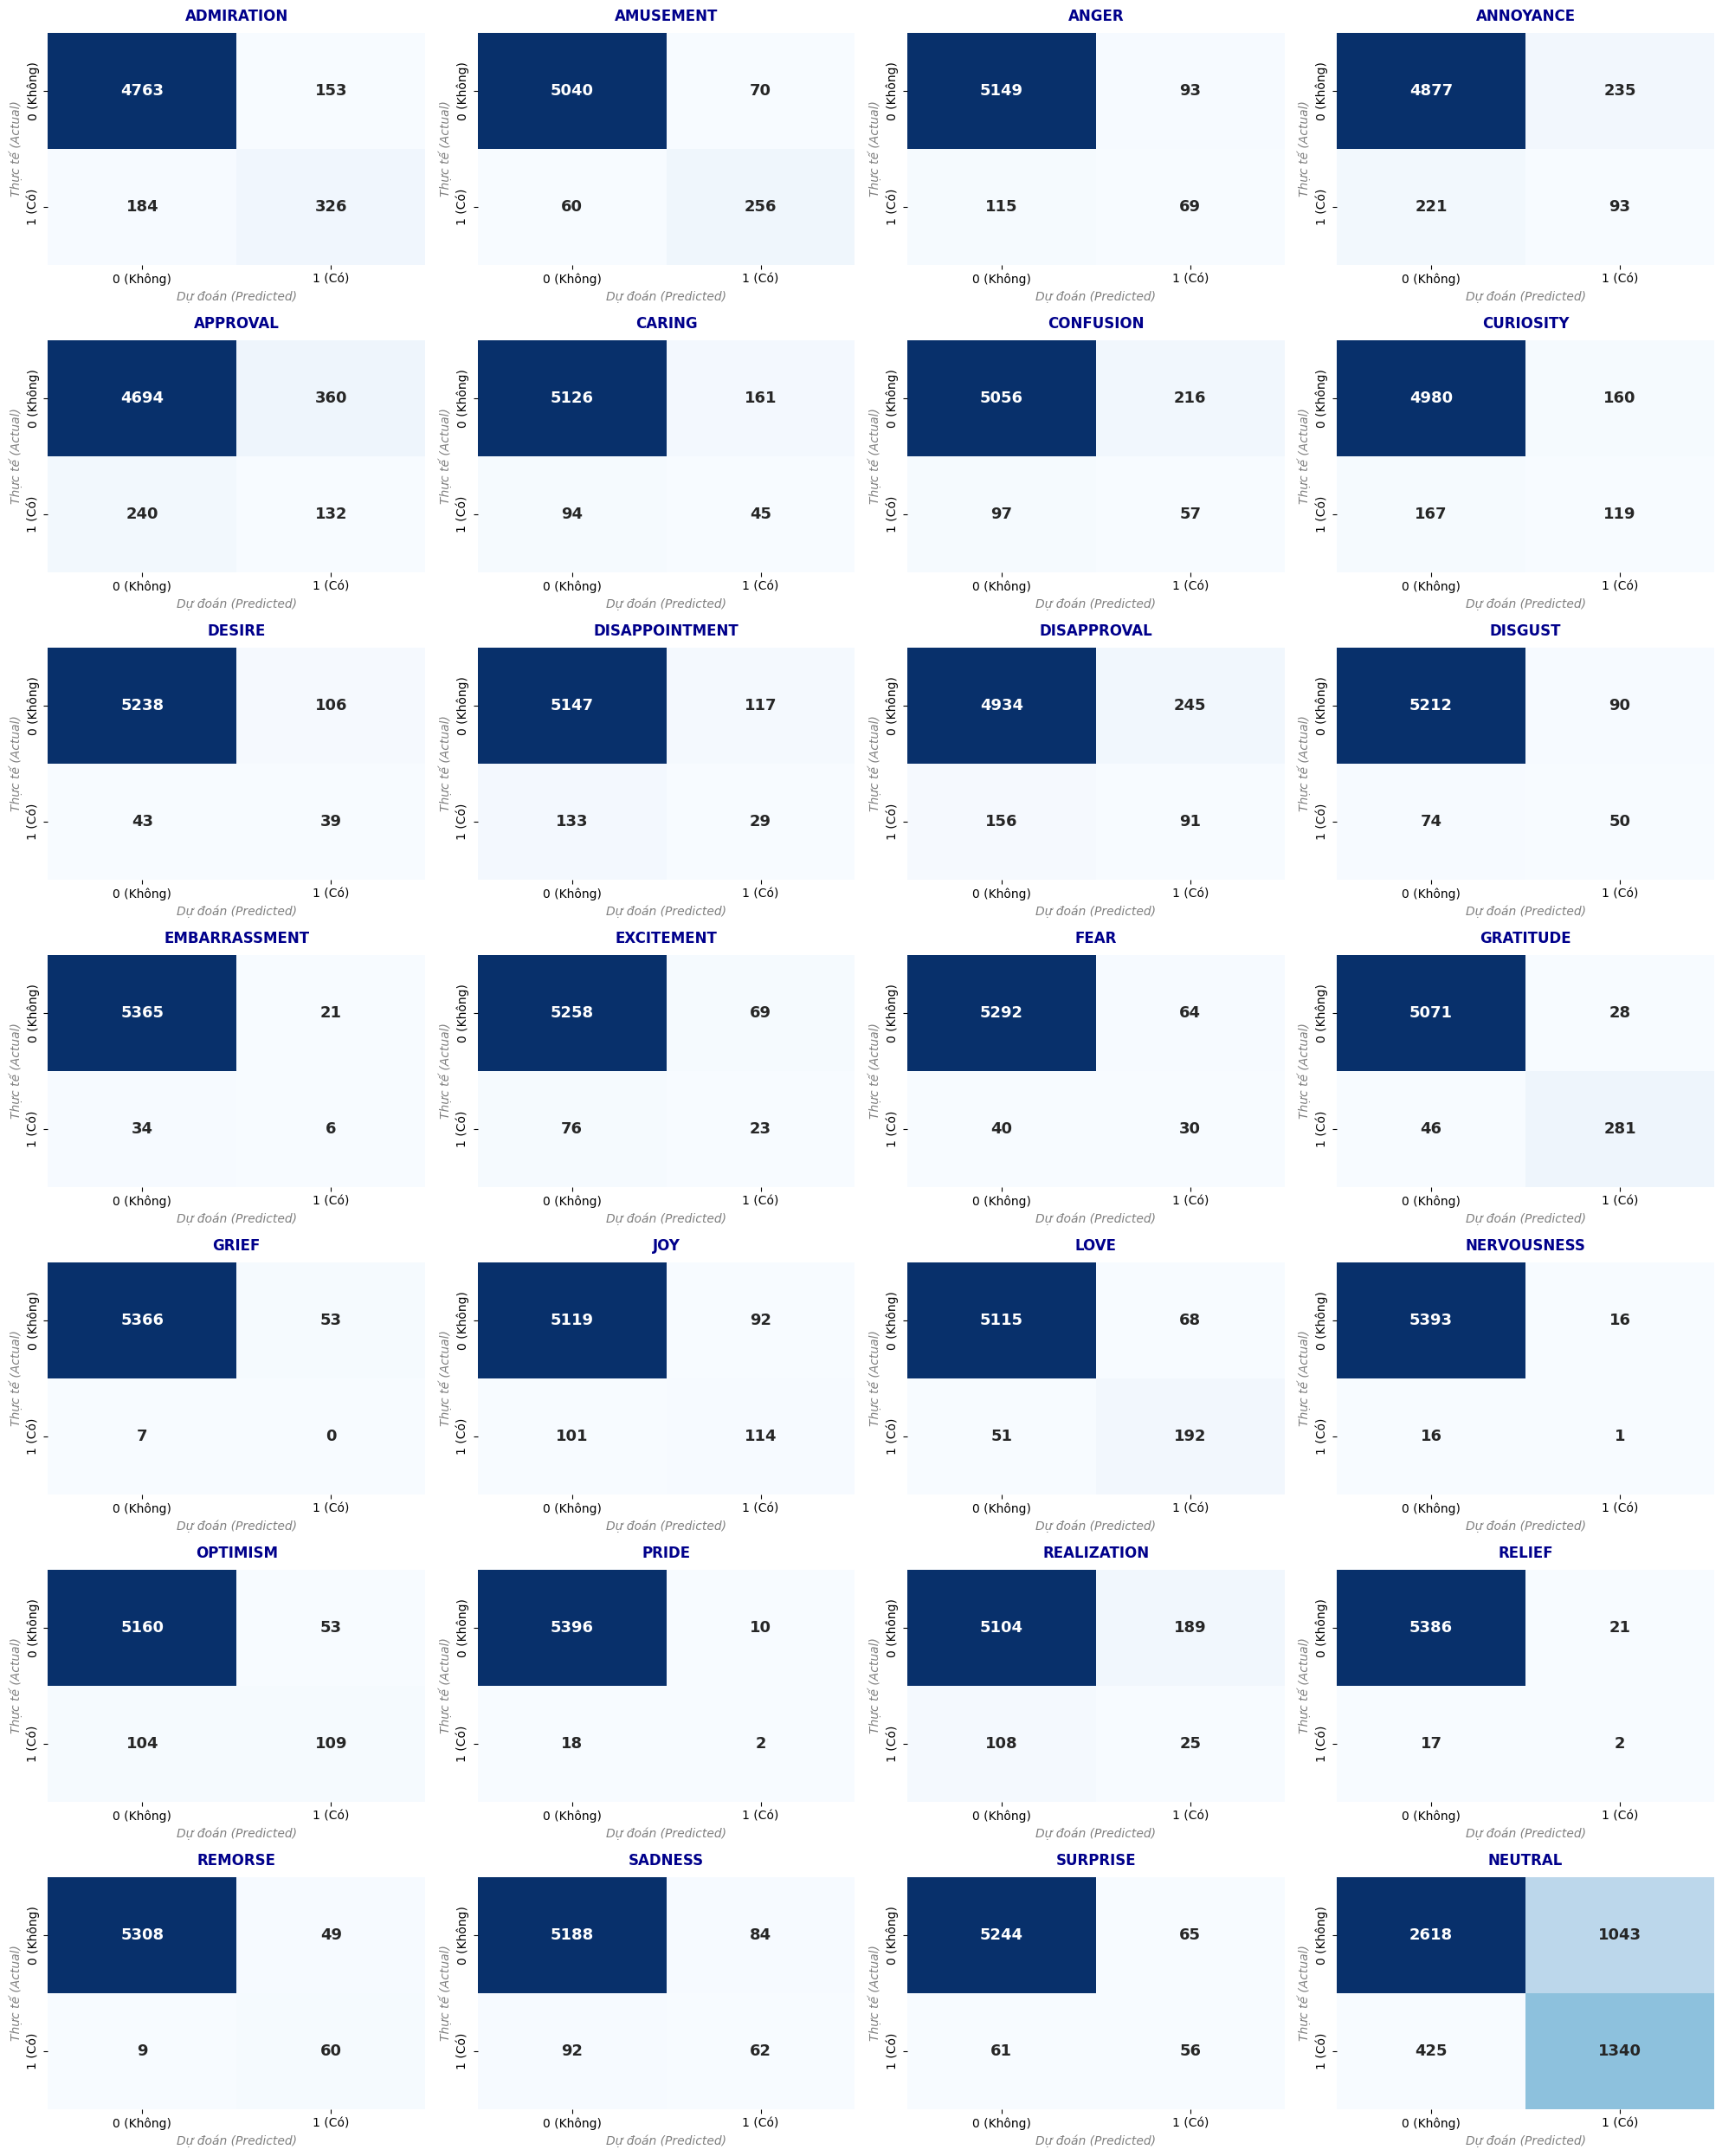

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

print("📊 ĐANG VẼ BỘ MA TRẬN NHẦM LẪN ĐA NHÃN (MULTI-LABEL CONFUSION MATRIX)...")
print("-" * 60)

# Ép kiểu an toàn (tránh lỗi nếu Y_test vẫn là Pandas DataFrame)
Y_test_array = Y_test.values if hasattr(Y_test, 'values') else Y_test

# Tính toán ma trận nhầm lẫn đa nhãn dựa trên kết quả tối ưu từ tập Test
mcm = multilabel_confusion_matrix(Y_test_array, Y_test_pred_binary)

# Khởi tạo khung vẽ: 7 hàng, 4 cột để vừa khít 28 nhãn
fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, label in enumerate(emotion_labels):
    ax = axes[idx]

    # Vẽ Heatmap cho từng nhãn
    sns.heatmap(
        mcm[idx],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['0 (Không)', '1 (Có)'],
        yticklabels=['0 (Không)', '1 (Có)'],
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"}
    )

    # Trang trí tiêu đề và trục
    ax.set_title(f"{label.upper()}", fontsize=12, fontweight='bold', color='darkblue', pad=10)
    ax.set_xlabel("Dự đoán (Predicted)", fontsize=10, color='gray', style='italic')
    ax.set_ylabel("Thực tế (Actual)", fontsize=10, color='gray', style='italic')

# Căn chỉnh để các biểu đồ không bị đè chữ lên nhau
plt.tight_layout()

# LƯU TỰ ĐỘNG: Xuất ra ảnh nét căng trước khi show để tránh bị lưu ảnh trắng
fig.savefig('MultiLabel_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
print("✅ Đã lưu đồ thị thành file 'MultiLabel_Confusion_Matrix.png' chất lượng cao!")

plt.show()

**Live test**

In [48]:
import ipywidgets as widgets
from IPython.display import display, clear_output
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# =====================================================
# HÀM DỰ ĐOÁN
# =====================================================

def predict_emotions(text):

    # PHẢI GIỐNG KHI TRAIN
    cleaned_text = clean_text_for_cnn(
        text,
        use_lemmatization=True
    )

    if cleaned_text == "":
        print("⚠️ Không có nội dung hợp lệ.")
        return

    seq = tokenizer.texts_to_sequences([cleaned_text])

    pad_seq = pad_sequences(
        seq,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    # DÙNG ĐÚNG MODEL ĐÃ TRAIN
    probs = model.predict(
        pad_seq,
        verbose=0
    )[0]

    detected_emotions = {}

    for i, label in enumerate(emotion_labels):

        if probs[i] >= best_thresholds[label]:
            detected_emotions[label] = probs[i]

    sorted_emotions = dict(
        sorted(
            detected_emotions.items(),
            key=lambda x: x[1],
            reverse=True
        )
    )

    print(f'📝 Câu gốc: "{text}"')
    print(f'🧹 Sau làm sạch: "{cleaned_text}"')

    print("\n🤖 XÁC SUẤT 28 NHÃN:")

    for i, label in enumerate(emotion_labels):

        status = "KÍCH HOẠT" if probs[i] >= best_thresholds[label] else "TẮT"

        print(
            f"   [{status:^9}] "
            f"{label.upper():15} "
            f"{probs[i]:.4f} "
            f"(Threshold={best_thresholds[label]:.2f})"
        )

    print("\n🎯 KẾT QUẢ CUỐI:")

    if len(sorted_emotions) == 0:
        print("   Không có cảm xúc nào vượt ngưỡng.")
    else:
        for emotion, prob in sorted_emotions.items():
            print(
                f"   ❤️ {emotion.capitalize():15} "
                f"{prob*100:.2f}%"
            )

    print("-" * 60)

# =====================================================
# GIAO DIỆN LIVE TEST
# =====================================================

text_input = widgets.Textarea(
    placeholder="Ví dụ: I am not happy with the service.",
    description="Text:",
    layout=widgets.Layout(
        width='80%',
        height='120px'
    )
)

analyze_button = widgets.Button(
    description='Phân tích',
    button_style='success',
    icon='search'
)

output_area = widgets.Output()

def on_button_clicked(b):

    with output_area:

        clear_output()

        text = text_input.value.strip()

        if text:
            predict_emotions(text)
        else:
            print("⚠️ Hãy nhập văn bản.")

analyze_button.on_click(on_button_clicked)

print("👇 LIVE TEST BI-LSTM + WORD2VEC 👇")

display(
    text_input,
    analyze_button,
    output_area
)

👇 LIVE TEST BI-LSTM + WORD2VEC 👇


Textarea(value='', description='Text:', layout=Layout(height='120px', width='80%'), placeholder='Ví dụ: I am n…

Button(button_style='success', description='Phân tích', icon='search', style=ButtonStyle())

Output()